# 07 -- Бэктест: Long-only top quintile, три exit rules

**Стратегия:** покупаем недооценённые корпоративные облигации РФ (Q5 по mispricing), ждём схождения цены к fair value, выходим. Equal-weight.

**Три exit rules:**
- **Rule C** (Monthly re-rank, baseline) -- держим месяц, ребалансируем
- **Rule A** (Half-life + z-score, primary) -- entry z>2, exit z<0.5 / z>3 / t>2*HL
- **Rule D** (Multi-signal, robustness) -- A + liquidity drying + rating downgrade

**Period split:**
- **Main**: 2021-01..2025-09 (~57 мес) -- основная разработка
- **Clean holdout**: 2025-10..2026-03 (6 мес) -- защита от data snooping

**Transaction costs:** Roll estimator из notebook 06; round-trip от 10 до 500 bps.

**Output:** `data/backtest_returns.csv`, `data/backtest_trades.csv`.

## Часть 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
    'font.family': 'DejaVu Sans',
    'axes.unicode_minus': False,
})

np.random.seed(42)

ROOT = Path('..').resolve()
SIGNAL_PATH = ROOT / 'data' / 'signal.csv'
MACRO_PATH = ROOT / 'data' / 'macro.csv'
OUT_RETURNS = ROOT / 'data' / 'backtest_returns.csv'
OUT_TRADES = ROOT / 'data' / 'backtest_trades.csv'
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# Hyperparameters
MAIN_END = pd.Timestamp('2025-09-30')
HOLDOUT_START = pd.Timestamp('2025-10-01')

N_MAX = 25                # max позиций в портфеле
Z_ENTER = 2.0             # entry threshold для Rules A, D
Z_EXIT  = 0.5             # profit-take threshold для Rules A, D
Z_STOP  = 3.0             # stop-loss threshold для Rules A, D
HL_MULT = 2.0             # time-stop multiplier для Rules A, D
LIQUIDITY_DRY = 1_000_000 # exit threshold для Rule D

print(f'SIGNAL_PATH : {SIGNAL_PATH}')
print(f'OUT_RETURNS : {OUT_RETURNS}')

SIGNAL_PATH : /repo/data/signal.csv
OUT_RETURNS : /repo/data/backtest_returns.csv


## Часть 2. Загрузка и расчёт дневных returns

In [2]:
sig = pd.read_csv(SIGNAL_PATH, parse_dates=['date'])
print(f'signal.csv: {sig.shape}')
print(f'  date range : {sig["date"].min().date()} .. {sig["date"].max().date()}')
print(f'  bonds      : {sig["isin"].nunique()}')

# Сортировка для shift
sig = sig.sort_values(['isin', 'date']).reset_index(drop=True)

# Daily price return (clean price). Coupon отдельно.
sig['close_prev'] = sig.groupby('isin')['close_price'].shift(1)
sig['price_return'] = sig['close_price'] / sig['close_prev'] - 1
# Filter extreme: price moves > 20% за день -- стейл/ошибка
sig.loc[sig['price_return'].abs() > 0.20, 'price_return'] = np.nan

# Daily coupon accrual: coupon_rate в % годовых, делим на 365
sig['coupon_daily'] = sig['coupon_rate'].fillna(0) / 100 / 365

# Total daily return
sig['total_return'] = sig['price_return'].fillna(0) + sig['coupon_daily']

print()
print('Daily total return distribution:')
print(sig['total_return'].describe().round(5))

signal.csv: (277966, 22)
  date range : 2021-01-04 .. 2026-03-30
  bonds      : 965

Daily total return distribution:
count    277966.00000
mean          0.00041
std           0.00766
min          -0.19840
25%          -0.00132
50%           0.00042
75%           0.00226
max           0.19857
Name: total_return, dtype: float64


## Часть 3. Rule C: Monthly re-rank (baseline)

**Логика:**
1. В последний торговый день месяца отбираем все tradable бумаги.
2. Среди них берём топ N_MAX по mispricing.
3. Equal-weight. Держим до конца следующего месяца.
4. Transaction costs: Roll/2 на каждый вход и выход.

Это **academic baseline** -- как делают Bai-Bali-Wen (2019), Gu-Kelly-Xiu (2020).

In [3]:
def select_portfolio_monthly(sig_df: pd.DataFrame, n_max: int = N_MAX) -> pd.DataFrame:
    """Возвращает список (rebalance_date, isins) -- что покупаем на каждом rebalance."""
    sig_df = sig_df.copy()
    sig_df['month'] = sig_df['date'].dt.to_period('M')
    
    selections = []
    for month, grp in sig_df.groupby('month'):
        # Берём последний день месяца с tradable=True
        last_date = grp['date'].max()
        day_df = grp[grp['date'] == last_date]
        # Tradable + Q5 + top by mispricing
        eligible = day_df[day_df['tradable'] == True].copy()
        eligible = eligible.sort_values('mispricing', ascending=False).head(n_max)
        selections.append({
            'rebalance_date': last_date,
            'month': month,
            'isins': eligible['isin'].tolist(),
            'roll_spreads': dict(zip(eligible['isin'], eligible['roll_spread_used'])),
        })
    return pd.DataFrame(selections)

selections_C = select_portfolio_monthly(sig)
print(f'Monthly portfolios: {len(selections_C)}')
print(f'Avg bonds per portfolio: {selections_C["isins"].apply(len).mean():.1f}')
selections_C.head()

Monthly portfolios: 62
Avg bonds per portfolio: 24.9


,rebalance_date,month,isins,roll_spreads
0,2021-01-29,2021-01,"[RU000A102952, RU000A102879, RU000A102986, RU0...","{'RU000A102952': 0.005, 'RU000A102879': 0.0015..."
1,2021-02-26,2021-02,"[RU000A101H84, RU000A100DZ5, RU000A0JX355, RU0...","{'RU000A101H84': 0.0121553884506405, 'RU000A10..."
2,2021-03-31,2021-03,"[RU000A0JT6B2, RU000A102D46, RU000A0JXE06, RU0...","{'RU000A0JT6B2': 0.005, 'RU000A102D46': 0.0069..."
3,2021-04-30,2021-04,"[RU000A1024L7, RU000A102SX4, RU000A1022E6, RU0...","{'RU000A1024L7': 0.0083392595342161, 'RU000A10..."
4,2021-05-31,2021-05,"[RU000A0JWN89, RU000A102879, RU000A0ZZ4T1, RU0...","{'RU000A0JWN89': 0.001, 'RU000A102879': 0.0045..."


In [4]:
def backtest_monthly(sig_df: pd.DataFrame, selections: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Возвращает (daily_returns, trades).
    
    Логика: открываем позиции на следующий день после rebalance_date,
    держим до следующего rebalance_date включительно.
    """
    sig_df = sig_df.copy()
    sig_df = sig_df.set_index(['date', 'isin'])
    
    daily_rows = []
    trade_rows = []
    
    selections = selections.sort_values('rebalance_date').reset_index(drop=True)
    for idx in range(len(selections) - 1):
        start = selections.iloc[idx]['rebalance_date']
        end = selections.iloc[idx + 1]['rebalance_date']
        isins = selections.iloc[idx]['isins']
        roll_spreads = selections.iloc[idx]['roll_spreads']
        if not isins:
            continue
        # Период владения: (start, end]
        period_dates = sig_df.index.get_level_values('date').unique()
        period_dates = sorted(d for d in period_dates if start < d <= end)
        
        # Trades: buy
        for isin in isins:
            cost_bps = roll_spreads.get(isin, 0.005) / 2
            trade_rows.append({'date': start, 'isin': isin, 'side': 'BUY', 'cost': cost_bps})
        
        # Daily returns
        for d in period_dates:
            rets = []
            for isin in isins:
                key = (d, isin)
                if key in sig_df.index:
                    rets.append(sig_df.loc[key, 'total_return'])
            if not rets:
                continue
            portfolio_ret = np.mean(rets)
            # Costs: на входе (start+1) и выходе (end)
            if d == period_dates[0]:
                avg_cost = np.mean([roll_spreads.get(i, 0.005) / 2 for i in isins])
                portfolio_ret -= avg_cost
            if d == period_dates[-1]:
                avg_cost = np.mean([roll_spreads.get(i, 0.005) / 2 for i in isins])
                portfolio_ret -= avg_cost
            daily_rows.append({'date': d, 'return': portfolio_ret, 'n_positions': len(isins)})
        
        # Trades: sell
        for isin in isins:
            cost_bps = roll_spreads.get(isin, 0.005) / 2
            trade_rows.append({'date': end, 'isin': isin, 'side': 'SELL', 'cost': cost_bps})
    
    return pd.DataFrame(daily_rows), pd.DataFrame(trade_rows)

print('Running Rule C backtest...')
rets_C, trades_C = backtest_monthly(sig, selections_C)
print(f'  daily rows : {len(rets_C):,}')
print(f'  trades     : {len(trades_C):,}')
rets_C.head()

Running Rule C backtest...


  daily rows : 1,282
  trades     : 3,032


,date,return,n_positions
0,2021-02-01,-0.000579,25
1,2021-02-02,0.000530,25
2,2021-02-03,-0.000639,25
3,2021-02-04,0.000737,25
4,2021-02-05,0.001225,25


## Часть 4. Rule A: Half-life + z-score (primary)

**Логика (state machine per bond):**
- Когда нет позиции: если `z > Z_ENTER (2.0)` AND `tradable` -> **открыть** (запомнить half_life на момент входа).
- Когда есть позиция, проверяем ежедневно:
  - `z < Z_EXIT (0.5)` -> закрыть (profit take, сигнал сошёлся).
  - `z > Z_STOP (3.0)` -> закрыть (stop loss, сигнал ухудшился).
  - `days_held > HL_MULT * half_life` (2x) -> закрыть (time stop).

**Литература:** Gatev-Goetzmann-Rouwenhorst (2006) для z-score thresholds, Bertram (2010) для time stops при mean-reverting процессе.

In [5]:
def compute_positions_signal_based(
    sig_df: pd.DataFrame,
    z_enter: float = Z_ENTER,
    z_exit: float = Z_EXIT,
    z_stop: float = Z_STOP,
    hl_mult: float = HL_MULT,
    extra_exits: bool = False,
    liquidity_dry: float = LIQUIDITY_DRY,
) -> pd.DataFrame:
    """Возвращает DataFrame с состоянием позиции (date, isin, in_position, entry, exit, exit_reason).
    
    extra_exits=True -> добавляет exits по liquidity_drying и rating_downgrade (Rule D).
    """
    out_rows = []
    for isin, grp in sig_df.groupby('isin'):
        grp = grp.sort_values('date').reset_index(drop=True)
        in_pos = False
        entry_date = None
        hl_entry = None
        rating_entry = None
        for _, row in grp.iterrows():
            entry_flag = False
            exit_flag = False
            exit_reason = ''
            days_held = 0
            if in_pos:
                days_held = (row['date'] - entry_date).days
                z = row['z_score']
                if not np.isfinite(z):
                    pass
                elif z < z_exit:
                    exit_flag = True; exit_reason = 'profit'
                elif z > z_stop:
                    exit_flag = True; exit_reason = 'stop'
                elif days_held > hl_mult * hl_entry:
                    exit_flag = True; exit_reason = 'time'
                if extra_exits and not exit_flag:
                    if pd.notna(row['volume_ma20']) and row['volume_ma20'] < liquidity_dry:
                        exit_flag = True; exit_reason = 'liquidity'
                    elif (pd.notna(row['rating_numeric']) and pd.notna(rating_entry)
                          and row['rating_numeric'] < rating_entry):
                        exit_flag = True; exit_reason = 'downgrade'
                if exit_flag:
                    out_rows.append({
                        'date': row['date'], 'isin': isin, 'in_position': True,
                        'entry': False, 'exit': True, 'exit_reason': exit_reason,
                        'days_held': days_held,
                    })
                    in_pos = False; entry_date = None; hl_entry = None; rating_entry = None
                else:
                    out_rows.append({
                        'date': row['date'], 'isin': isin, 'in_position': True,
                        'entry': False, 'exit': False, 'exit_reason': '',
                        'days_held': days_held,
                    })
            else:
                z = row['z_score']
                if (np.isfinite(z) and z > z_enter and bool(row['tradable'])
                    and np.isfinite(row['half_life_used'])):
                    entry_flag = True
                    in_pos = True
                    entry_date = row['date']
                    hl_entry = row['half_life_used']
                    rating_entry = row['rating_numeric']
                    out_rows.append({
                        'date': row['date'], 'isin': isin, 'in_position': True,
                        'entry': True, 'exit': False, 'exit_reason': '',
                        'days_held': 0,
                    })
    return pd.DataFrame(out_rows)

print('Computing Rule A positions...')
pos_A = compute_positions_signal_based(sig, extra_exits=False)
print(f'  position-days: {len(pos_A):,}')
print(f'  entries     : {pos_A["entry"].sum():,}')
print(f'  exits       : {pos_A["exit"].sum():,}')
print(f'  exit reasons:')
print(pos_A[pos_A['exit']]['exit_reason'].value_counts())

Computing Rule A positions...


  position-days: 1,781
  entries     : 596
  exits       : 593
  exit reasons:
exit_reason
stop      345
profit    221
time       27
Name: count, dtype: int64


In [6]:
def backtest_signal_based(
    sig_df: pd.DataFrame,
    positions: pd.DataFrame,
    n_max: int = N_MAX,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Бэктест на основе positions (Rule A или D).
    
    Equal-weight среди удерживаемых позиций. Если N > n_max, оставляем top по z_score.
    """
    # Merge total_return
    pos = positions.merge(
        sig_df[['date', 'isin', 'total_return', 'z_score', 'roll_spread_used']],
        on=['date', 'isin'], how='left'
    )
    
    trade_rows = []
    for _, r in pos[pos['entry']].iterrows():
        trade_rows.append({'date': r['date'], 'isin': r['isin'], 'side': 'BUY',
                           'cost': r['roll_spread_used'] / 2})
    for _, r in pos[pos['exit']].iterrows():
        trade_rows.append({'date': r['date'], 'isin': r['isin'], 'side': 'SELL',
                           'cost': r['roll_spread_used'] / 2,
                           'exit_reason': r['exit_reason'], 'days_held': r['days_held']})
    trades = pd.DataFrame(trade_rows)
    
    # Daily portfolio return
    daily_rows = []
    for d, grp in pos[pos['in_position']].groupby('date'):
        # Cap at n_max
        if len(grp) > n_max:
            grp = grp.nlargest(n_max, 'z_score')
        n = len(grp)
        if n == 0:
            continue
        ret = grp['total_return'].fillna(0).mean()
        # Costs
        entry_cost = grp[grp['entry']]['roll_spread_used'].sum() / 2 / n
        exit_cost  = grp[grp['exit']]['roll_spread_used'].sum() / 2 / n
        ret -= entry_cost + exit_cost
        daily_rows.append({
            'date': d,
            'return': ret,
            'n_positions': n,
            'n_entries': int(grp['entry'].sum()),
            'n_exits': int(grp['exit'].sum()),
        })
    return pd.DataFrame(daily_rows), trades

print('Running Rule A backtest...')
rets_A, trades_A = backtest_signal_based(sig, pos_A)
print(f'  daily rows : {len(rets_A):,}')
print(f'  trades     : {len(trades_A):,}')
print(f'  avg n_pos  : {rets_A["n_positions"].mean():.1f}')

Running Rule A backtest...
  daily rows : 787
  trades     : 1,189
  avg n_pos  : 2.3


## Часть 5. Rule D: Multi-signal (robustness)

Все exits Rule A + два дополнительных:
- `volume_ma20 < 1M RUB` -- liquidity drying
- `rating_numeric < rating_at_entry` -- rating downgrade

In [7]:
print('Computing Rule D positions...')
pos_D = compute_positions_signal_based(sig, extra_exits=True)
print(f'  entries: {pos_D["entry"].sum():,}, exits: {pos_D["exit"].sum():,}')
print(f'  exit reasons:')
print(pos_D[pos_D['exit']]['exit_reason'].value_counts())
print()
print('Running Rule D backtest...')
rets_D, trades_D = backtest_signal_based(sig, pos_D)
print(f'  daily rows: {len(rets_D):,}, avg n_pos: {rets_D["n_positions"].mean():.1f}')

Computing Rule D positions...


  entries: 596, exits: 593
  exit reasons:
exit_reason
stop         345
profit       220
time          27
liquidity      1
Name: count, dtype: int64

Running Rule D backtest...
  daily rows: 785, avg n_pos: 2.3


## Часть 6. Метрики

Считаем для каждой стратегии × 2 периода:
- Total return, CAGR
- Sharpe (annualized, daily √252)
- Sortino (downside √252)
- MaxDD, Calmar
- Hit rate, Profit factor (по дневным returns)
- Turnover (для signal-based -- из trades)

In [8]:
def calc_metrics(rets: pd.DataFrame, name: str = '') -> dict:
    """Метрики из daily returns DataFrame ['date','return',...]."""
    if len(rets) == 0:
        return {'name': name, 'n_days': 0}
    r = rets['return'].values
    eq = np.cumprod(1 + r)
    total_return = eq[-1] - 1
    n_days = len(r)
    n_years = n_days / 252
    cagr = eq[-1] ** (1 / n_years) - 1 if n_years > 0 else np.nan
    sharpe = np.sqrt(252) * r.mean() / r.std() if r.std() > 0 else np.nan
    downside = r[r < 0]
    sortino = np.sqrt(252) * r.mean() / downside.std() if len(downside) > 1 and downside.std() > 0 else np.nan
    # MaxDD
    peak = np.maximum.accumulate(eq)
    dd = (eq - peak) / peak
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan
    hit_rate = (r > 0).mean()
    gains = r[r > 0].sum()
    losses = -r[r < 0].sum()
    pf = gains / losses if losses > 0 else np.nan
    return {
        'name': name,
        'n_days': n_days,
        'total_return': total_return,
        'CAGR': cagr,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'MaxDD': max_dd,
        'Calmar': calmar,
        'Hit rate': hit_rate,
        'Profit factor': pf,
        'avg n_positions': rets['n_positions'].mean(),
    }


def split_main_holdout(rets: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    main = rets[rets['date'] <= MAIN_END].copy()
    holdout = rets[rets['date'] >= HOLDOUT_START].copy()
    return main, holdout

results = []
for name, rets in [('C: Monthly', rets_C), ('A: HL+zscore', rets_A), ('D: Multi-signal', rets_D)]:
    main, holdout = split_main_holdout(rets)
    results.append(calc_metrics(main, f'{name} (Main)'))
    results.append(calc_metrics(holdout, f'{name} (Holdout)'))

metrics = pd.DataFrame(results)
metrics_disp = metrics.set_index('name').T
metrics_disp

name,C: Monthly (Main),C: Monthly (Holdout),A: HL+zscore (Main),A: HL+zscore (Holdout),D: Multi-signal (Main),D: Multi-signal (Holdout)
n_days,1159.000000,123.000000,690.000000,97.000000,688.000000,97.000000
total_return,0.205209,0.041731,-0.598798,-0.456890,-0.600037,-0.456890
CAGR,0.041418,0.087371,-0.283624,-0.795236,-0.285128,-0.795236
Sharpe,0.825352,1.408291,-1.177193,-3.563756,-1.183291,-3.563756
Sortino,0.760789,1.321633,-1.407225,-3.586152,-1.416928,-3.586152
MaxDD,-0.134785,-0.043520,-0.690085,-0.528411,-0.691041,-0.528411
Calmar,0.307292,2.007615,-0.410998,-1.504958,-0.412606,-1.504958
Hit rate,0.592752,0.609756,0.418841,0.371134,0.417151,0.371134
Profit factor,1.233955,1.325096,0.685662,0.393571,0.684938,0.393571
avg n_positions,24.836928,25.000000,2.288406,2.082474,2.287791,2.082474


## Часть 7. Passive benchmark (equal-weight all tradable bonds)

Бенчмарк -- equal-weight всех бумаг tradable=True на каждую дату.
Это passive bond exposure без mispricing-сигнала.

Примечание: RUCBITR/RGBITR не подгружены, для научника можно добавить отдельной строкой.

In [9]:
def equal_weight_benchmark(sig_df: pd.DataFrame) -> pd.DataFrame:
    """Equal-weight по tradable бумагам с total_return."""
    tradable = sig_df[sig_df['tradable'] == True].copy()
    bench = tradable.groupby('date').agg(
        return_=('total_return', 'mean'),
        n_positions=('isin', 'count'),
    ).reset_index().rename(columns={'return_': 'return'})
    return bench

bench = equal_weight_benchmark(sig)
print(f'Benchmark: {len(bench)} days, avg N={bench["n_positions"].mean():.0f}')

main_b, hold_b = split_main_holdout(bench)
results_bench = [calc_metrics(main_b, 'Bench EW (Main)'), calc_metrics(hold_b, 'Bench EW (Holdout)')]
pd.DataFrame(results_bench).set_index('name').T

Benchmark: 1301 days, avg N=85


name,Bench EW (Main),Bench EW (Holdout)
n_days,1178.000000,123.000000
total_return,0.474047,0.066820
CAGR,0.086546,0.141701
Sharpe,1.643126,5.846938
Sortino,1.330108,7.592924
MaxDD,-0.147375,-0.013082
Calmar,0.587251,10.831559
Hit rate,0.635823,0.699187
Profit factor,1.597730,2.650548
avg n_positions,69.167233,241.764228


## Часть 8. Графики: equity curves, drawdowns

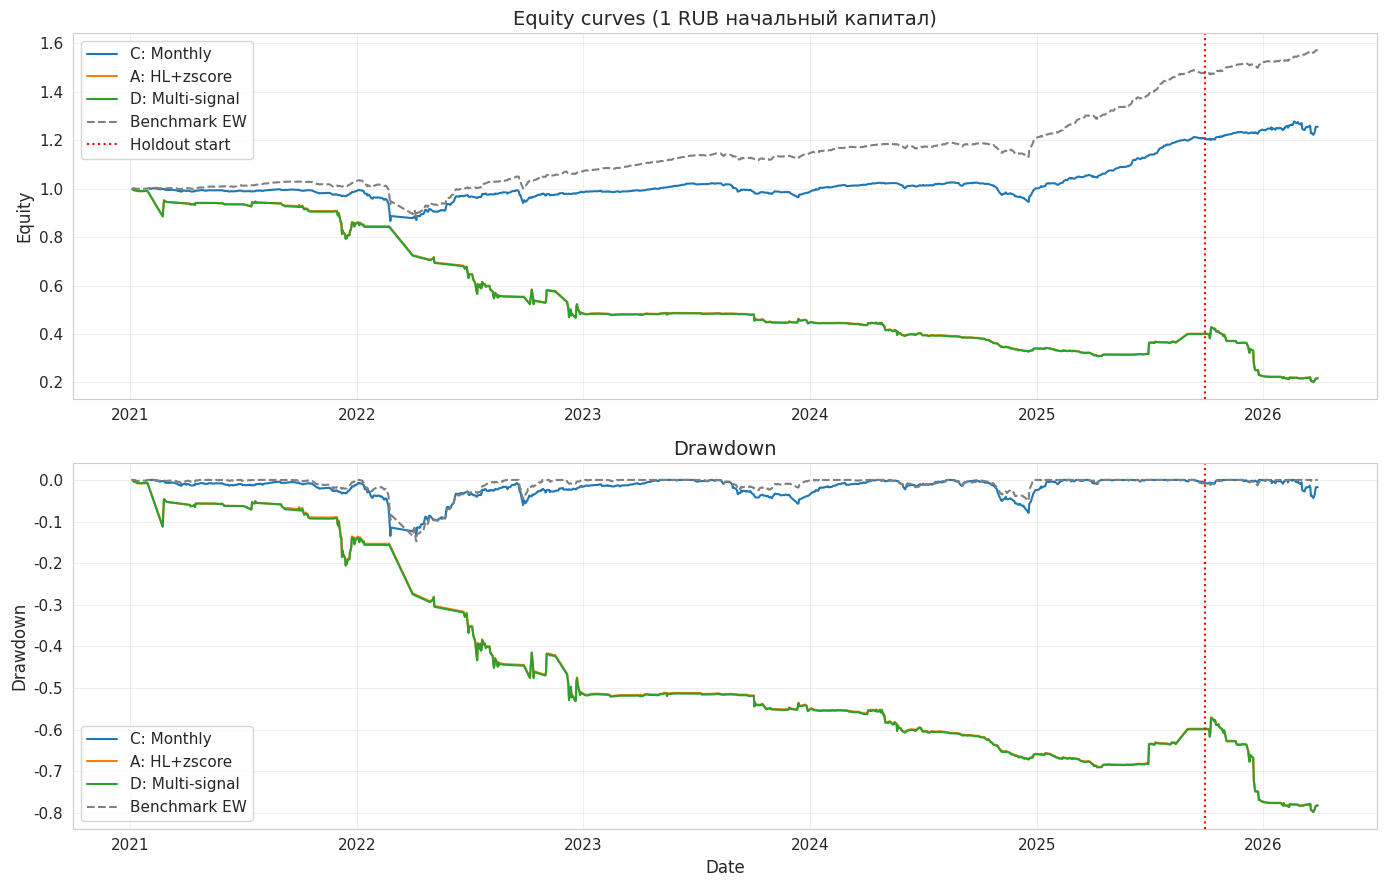

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for name, rets, color in [
    ('C: Monthly', rets_C, 'tab:blue'),
    ('A: HL+zscore', rets_A, 'tab:orange'),
    ('D: Multi-signal', rets_D, 'tab:green'),
    ('Benchmark EW', bench, 'gray'),
]:
    r = rets.sort_values('date')
    eq = (1 + r['return']).cumprod()
    axes[0].plot(r['date'], eq, label=name, color=color, linewidth=1.5,
                 linestyle='--' if name.startswith('Bench') else '-')
    # Drawdown
    peak = eq.cummax()
    dd = (eq - peak) / peak
    axes[1].plot(r['date'], dd, label=name, color=color, linewidth=1.5,
                 linestyle='--' if name.startswith('Bench') else '-')

axes[0].axvline(MAIN_END, color='red', linestyle=':', label='Holdout start')
axes[0].set_title('Equity curves (1 RUB начальный капитал)')
axes[0].set_ylabel('Equity')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].axvline(MAIN_END, color='red', linestyle=':')
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '07_equity_drawdown.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 9. Monthly returns heatmap (Rule A)

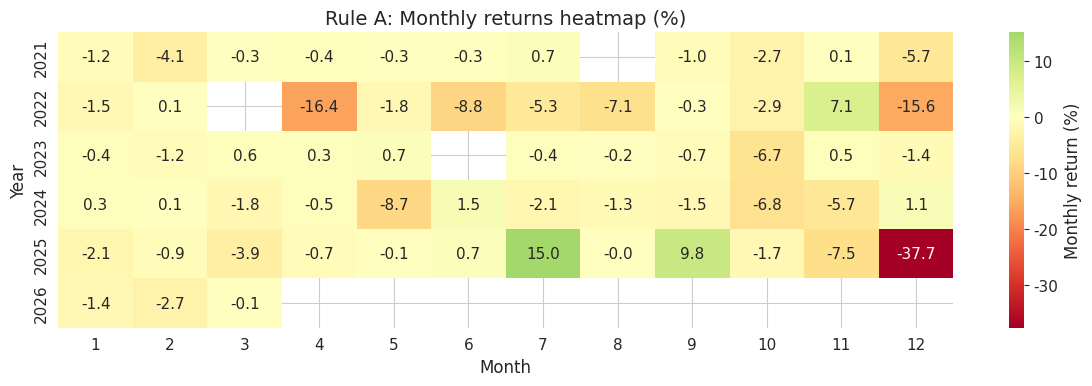

In [11]:
rets_A_m = rets_A.copy()
rets_A_m['year'] = rets_A_m['date'].dt.year
rets_A_m['month'] = rets_A_m['date'].dt.month
monthly = rets_A_m.groupby(['year', 'month']).apply(
    lambda g: (1 + g['return']).prod() - 1
).reset_index(name='monthly_return')
pivot = monthly.pivot(index='year', columns='month', values='monthly_return')

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot * 100, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Monthly return (%)'}, ax=ax)
ax.set_title('Rule A: Monthly returns heatmap (%)')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_monthly_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 10. Sub-period analysis (замечание научника о 2022)

- **Regime A**: 2021-01-04 .. 2022-02-23 (pre-СВО)
- **Regime B**: 2022-02-24 .. 2022-12-31 (шок)
- **Regime C**: 2023-01-01 .. 2025-09-30 (новая норма)

In [12]:
regimes = [
    ('A: pre-СВО', pd.Timestamp('2021-01-04'), pd.Timestamp('2022-02-23')),
    ('B: шок 2022', pd.Timestamp('2022-02-24'), pd.Timestamp('2022-12-31')),
    ('C: норма', pd.Timestamp('2023-01-01'), MAIN_END),
]

sub_results = []
for rname, rets in [('C: Monthly', rets_C), ('A: HL+zscore', rets_A), ('D: Multi-signal', rets_D)]:
    for regname, start, end in regimes:
        sub = rets[(rets['date'] >= start) & (rets['date'] <= end)]
        m = calc_metrics(sub, f'{rname} | {regname}')
        sub_results.append(m)

sub_df = pd.DataFrame(sub_results)
sub_df[['name', 'n_days', 'Sharpe', 'MaxDD', 'CAGR', 'Hit rate']].round(3)

,name,n_days,Sharpe,MaxDD,CAGR,Hit rate
0,C: Monthly | A: pre-СВО,271,-2.160,-0.083,-0.076,0.491
1,C: Monthly | B: шок 2022,192,1.006,-0.054,0.096,0.609
2,C: Monthly | C: норма,696,2.124,-0.079,0.076,0.628
3,A: HL+zscore | A: pre-СВО,114,-1.428,-0.204,-0.310,0.404
4,A: HL+zscore | B: шок 2022,81,-2.753,-0.354,-0.820,0.358
5,A: HL+zscore | C: норма,495,-0.553,-0.366,-0.094,0.432
6,D: Multi-signal | A: pre-СВО,112,-1.469,-0.206,-0.320,0.393
7,D: Multi-signal | B: шок 2022,81,-2.753,-0.354,-0.820,0.358
8,D: Multi-signal | C: норма,495,-0.553,-0.366,-0.094,0.432


## Часть 11. Распределение P&L по сделкам (Rule A)

In [13]:
# Сопоставление BUY и SELL по isin -- считаем return за hold period
def trade_pnl(positions: pd.DataFrame, sig_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for isin, grp in positions.groupby('isin'):
        grp = grp.sort_values('date').reset_index(drop=True)
        entries = grp[grp['entry']].index.tolist()
        exits = grp[grp['exit']].index.tolist()
        for ei, xi in zip(entries, exits):
            entry_date = grp.loc[ei, 'date']
            exit_date = grp.loc[xi, 'date']
            mask = (sig_df['isin'] == isin) & (sig_df['date'] >= entry_date) & (sig_df['date'] <= exit_date)
            trade_rets = sig_df.loc[mask, 'total_return']
            cum_ret = (1 + trade_rets).prod() - 1
            cost = sig_df.loc[(sig_df['isin'] == isin) & (sig_df['date'] == entry_date), 'roll_spread_used'].values
            cost = cost[0] if len(cost) else 0.005
            net_ret = cum_ret - cost  # round-trip cost
            rows.append({
                'isin': isin, 'entry_date': entry_date, 'exit_date': exit_date,
                'days_held': (exit_date - entry_date).days,
                'gross_return': cum_ret, 'cost': cost, 'net_return': net_ret,
                'exit_reason': grp.loc[xi, 'exit_reason'],
            })
    return pd.DataFrame(rows)

print('Computing trade-level P&L for Rule A...')
pnl_A = trade_pnl(pos_A, sig)
print(f'  trades: {len(pnl_A):,}')
print(f'  mean net return: {pnl_A["net_return"].mean() * 100:.2f}%')
print(f'  median hold days: {pnl_A["days_held"].median():.0f}')
print()
print('By exit reason:')
print(pnl_A.groupby('exit_reason')['net_return'].agg(['count', 'mean', 'std']).round(4))

Computing trade-level P&L for Rule A...


  trades: 593
  mean net return: -0.50%
  median hold days: 2

By exit reason:
             count    mean     std
exit_reason                       
profit         221 -0.0013  0.0264
stop           345 -0.0074  0.0215
time            27 -0.0047  0.0491


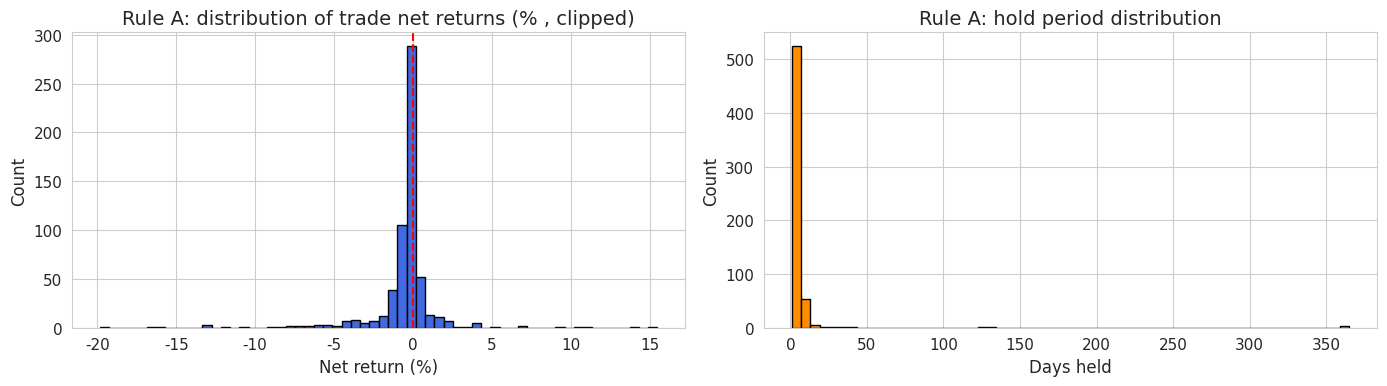

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ret_pct = (pnl_A['net_return'] * 100).clip(-20, 20)
axes[0].hist(ret_pct, bins=60, color='royalblue', edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title(f'Rule A: distribution of trade net returns (% , clipped)')
axes[0].set_xlabel('Net return (%)')
axes[0].set_ylabel('Count')

axes[1].hist(pnl_A['days_held'].clip(0, 365), bins=60, color='darkorange', edgecolor='black')
axes[1].set_title('Rule A: hold period distribution')
axes[1].set_xlabel('Days held')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(FIG_DIR / '07_trade_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 12. Сохранение результатов

In [15]:
rets_C['rule'] = 'C'
rets_A['rule'] = 'A'
rets_D['rule'] = 'D'
all_rets = pd.concat([rets_C, rets_A, rets_D], ignore_index=True)
all_rets.to_csv(OUT_RETURNS, index=False)
print(f'Saved: {OUT_RETURNS} ({len(all_rets):,} rows)')

trades_C['rule'] = 'C'
trades_A['rule'] = 'A'
trades_D['rule'] = 'D'
all_trades = pd.concat([trades_C, trades_A, trades_D], ignore_index=True)
all_trades.to_csv(OUT_TRADES, index=False)
print(f'Saved: {OUT_TRADES} ({len(all_trades):,} rows)')

metrics.to_csv(ROOT / 'data' / 'backtest_metrics.csv', index=False)
sub_df.to_csv(ROOT / 'data' / 'backtest_subperiod.csv', index=False)
pnl_A.to_csv(ROOT / 'data' / 'backtest_trade_pnl_A.csv', index=False)
print('Saved: backtest_metrics.csv, backtest_subperiod.csv, backtest_trade_pnl_A.csv')

Saved: /repo/data/backtest_returns.csv (2,854 rows)
Saved: /repo/data/backtest_trades.csv (5,410 rows)
Saved: backtest_metrics.csv, backtest_subperiod.csv, backtest_trade_pnl_A.csv


## Часть 13. Итоги

**Что готово:**
- 3 стратегии (C, A, D) × 2 периода (Main, Holdout)
- Equity curves, drawdowns, monthly heatmap, trade P&L distribution
- Sub-period analysis (Regime A/B/C, замечание научника о 2022)
- Все daily returns и trades сохранены в `data/backtest_*.csv`

**Дальше (Notebook 08):**
- Block bootstrap для CI Sharpe
- Sensitivity to N, transaction costs, thresholds
- Out-of-universe test
- Survivorship bias discussion